### **Imports**

In [1]:
import pickle, os
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import wilcoxon
from utils_jgm.tikz_pgf_helpers import tpl_save
import matplot2tikz

def p_to_star(p):
    if p < 0.005:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'n.s.'

FIGSIZE = (14, 4); DPI = 600
FIGSIZE_SINGLE = (14, 4)
TICK_FONTSIZE_X_and_Y = 14; TITLE_FONTSIZE = 14; YLABEL_FONTSIZE = 14
COLORS = ["skyblue", "lightgreen", "salmon", "seashell"]


### **Main comparison figure (PCC & STOI)**

In [ ]:
# ------------------------
# Load result files 
# ------------------------
files = {
    "Linear": "/home/ahmed348/TCNN_repo/pkl_files/Linear_HGA_ONLY.pkl",
    "Vocalmind": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_VOCALMIND_vocalmind_7500_T_6.pkl", ## verified, this uses HGA-LFC
    "TCNN": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order = list(files.keys())

# ------------------------
# Create figure with 2 subplots (PCC and STOI)
# ------------------------
metrics = ["PCC", "STOI"]
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
stoi_differences = []
all_pcc_scores = []; all_pcc_scores_linear = []; all_pcc_scores_vocalmind = []
subjectwise_pcc_stats = []

for ax_idx, metric in enumerate(metrics):
    # Load data for this metric
    results = {}
    for method, fpath in files.items():
        with open(fpath, "rb") as f:
            data = pickle.load(f)
            results[method] = data[metric]  # list of n_subjects, each with 10 folds

    # ------------------------
    # Prepare boxplot data
    # ------------------------
    n_subjects = len(next(iter(results.values())))   # should be 10
    methods = list(results.keys())
    n_methods = len(methods)

    positions = []
    box_data = []
    labels = []
    width = 0.18  # spacing between methods

    for subj_idx in range(n_subjects):
        for m_idx, method in enumerate(methods):
            subj_data = results[method][subj_idx]  # list of folds for this subject
            box_data.append(subj_data)
            positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
            labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

    # ------------------------
    # Plot boxplot
    # ------------------------
    ax = axes[ax_idx]
    bp = ax.boxplot(
        box_data,
        positions=positions,
        vert=True,
        widths=0.75*width,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'linewidth': 1.5, 'color': 'black'},
        capprops={'linewidth': 1.5, 'color': 'black'},
        boxprops={'linewidth': 1.5},
    )

    # Assign colors
    for m_idx, color in enumerate(COLORS[:n_methods]):
        for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
            bp["boxes"][patch_idx].set_facecolor(color)

    # X-axis ticks at subject centers
    ax.set_xticks(range(1, n_subjects+1))
    ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

    ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
    # if ax_idx == 0:
    #     ax.set_title(f"Comparison between models", fontsize=TITLE_FONTSIZE)

    ax.grid(True)

    # Extend ylim for stars
    data_list = box_data
    all_data = np.concatenate(data_list)
    yrange = all_data.max() - all_data.min()
    ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)

    # Significance stars
    pairs = [("Linear", "TCNN"), ("Vocalmind", "TCNN")]
    m_bonf = len(pairs)   # keep original variable name
    base_offset = yrange * 0.05
    bracket_width = yrange * 0.03

    for s_idx in range(n_subjects):
        start_idx = s_idx * n_methods
        subj_positions = [positions[start_idx + m] for m in range(n_methods)]
        subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
        ymax = max(max(arr) for arr in subj_data_arrays)

        raw_pvals = []

        # ---- FIRST PASS: compute raw p-values (keep all variables) ----
        for level, (m1, m2) in enumerate(pairs):
            m1_idx = method_order.index(m1)
            m2_idx = method_order.index(m2)

            a, b = results[m1][s_idx], results[m2][s_idx]

            if metric == "PCC" and m1 == "Vocalmind":
                stoi_differences.append(100 * (np.mean(b) - np.mean(a)) / np.mean(b))
                all_pcc_scores_vocalmind.append(a) 
                # a_mean = np.mean(np.array(a)); a_std = np.std(np.array(a))
                # print(f'subject {s_idx} (vocalmind) : {a_mean}+-{a_std}')
            if metric == "PCC" and m2 == "TCNN" and level==0:
                all_pcc_scores.append(b) 
                # b_mean = np.mean(np.array(b)); b_std = np.std(np.array(b))
                # print(f'subject {s_idx} (tcnn): {b_mean}+-{b_std}')
            if metric == "PCC" and m1 == "Linear": ## level=0 for linear
                all_pcc_scores_linear.append(a) 
                a_mean = np.mean(np.array(a)); a_std = np.std(np.array(a))
                print(f'subject {s_idx} (linear) : {a_mean}+-{a_std}')
            try:
                _, pval = wilcoxon(b, a, alternative='greater')
            except Exception:
                pval = 1.0
            raw_pvals.append(pval)

        # ---- Holm–Bonferroni correction ----
        sorted_idx = np.argsort(raw_pvals)
        sorted_pvals = np.array(raw_pvals)[sorted_idx]
        holm_adjusted = np.empty_like(sorted_pvals)

        for k, p in enumerate(sorted_pvals):
            holm_adjusted[k] = min(p * (m_bonf - k), 1.0)

        # enforce monotonicity
        for k in range(1, m_bonf):
            holm_adjusted[k] = max(holm_adjusted[k], holm_adjusted[k-1])

        # restore original order
        p_adj_all = np.empty_like(holm_adjusted)
        p_adj_all[sorted_idx] = holm_adjusted

        # ---- SECOND PASS: use adjusted p-values (structure unchanged) ----
        for level, (m1, m2) in enumerate(pairs):
            m1_idx = method_order.index(m1)
            m2_idx = method_order.index(m2)

            p_adj = p_adj_all[level]
            stars = p_to_star(p_adj)

            x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
            y = ymax + base_offset + level * (base_offset + bracket_width)

            ax.plot([x1, x1, x2, x2],
                    [y, y+bracket_width, y+bracket_width, y],
                    lw=1.2, c='black')
            ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.97])  # leave space at top for legend
fig.legend(
    handles=[plt.Line2D([], [], color=COLORS[i], linewidth=10, label=method) for i, method in enumerate(methods)],
    loc='upper center',
    ncol=len(methods),
    frameon=False,
    fontsize=11
)
### plt.savefig('/home/ahmed348/TCNN_repo/figures/main_comparison_figure.pdf', bbox_inches='tight', dpi=DPI)
# plt.show()
# print(np.mean(np.array(stoi_differences)))  ## percentage improvement in STOI
all_pcc_scores_cat = sum(all_pcc_scores, [])
all_pcc_scores_vocalmind_cat = sum(all_pcc_scores_vocalmind, [])
all_pcc_scores_linear_cat = sum(all_pcc_scores_linear, [])
print(len(all_pcc_scores_linear_cat)); print(len(all_pcc_scores_vocalmind_cat)); print(len(all_pcc_scores_cat))
print(f'mean +- std for pcc (linear) : {np.mean(np.array(all_pcc_scores_linear_cat))} +- {np.std(np.array(all_pcc_scores_linear_cat))}')
print(f'mean +- std for pcc (vocalmind): {np.mean(np.array(all_pcc_scores_vocalmind_cat))} +- {np.std(np.array(all_pcc_scores_vocalmind_cat))}')
print(f'mean +- std for pcc (tcnn): {np.mean(np.array(all_pcc_scores_cat))} +- {np.std(np.array(all_pcc_scores_cat))}')

### **Main comparison figure (STOI only)**

In [ ]:
# ------------------------
# Load result files
# ------------------------
files = {
    "Linear": "/home/ahmed348/TCNN_repo/pkl_files/Linear_HGA_ONLY.pkl",
    "Vocalmind": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_VOCALMIND_vocalmind_7500_T_6.pkl",
    "TCNN": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order = list(files.keys())

# ------------------------
# Only plot STOI
# ------------------------
metric = "STOI"
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)  # single plot
stoi_differences = []

# Load data for this metric
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []
width = 0.18  # spacing between methods
colors = COLORS 
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot boxplot
# ------------------------
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors
for m_idx, color in enumerate(COLORS[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"P{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods", loc='lower right')
ax.grid(True)

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.05, all_data.max() + yrange*0.39)

# Significance stars
pairs = [("Linear", "TCNN"), ("Vocalmind", "TCNN")]
m_bonf = len(pairs)
base_offset = yrange * 0.05
bracket_width = yrange * 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)
    raw_pvals = []
    # --- FIRST LOOP: compute raw p-values (UNCHANGED structure) ---
    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        a, b = results[m1][s_idx], results[m2][s_idx]
        if m1 == "Vocalmind":
            stoi_differences.append(100*(np.mean(b)-np.mean(a))/np.mean(b))
        try:
            _, pval = wilcoxon(b, a, alternative='greater')
        except Exception:
            pval = 1.0
        raw_pvals.append(pval)

    # --- HOLM-BONFERRONI (replaces simple Bonferroni) ---
    sorted_idx = np.argsort(raw_pvals)
    sorted_pvals = np.array(raw_pvals)[sorted_idx]
    holm_adjusted = np.empty_like(sorted_pvals)

    for k, p in enumerate(sorted_pvals):
        holm_adjusted[k] = min(p * (m_bonf - k), 1.0)

    for k in range(1, m_bonf):
        holm_adjusted[k] = max(holm_adjusted[k], holm_adjusted[k-1])
    p_adj_all = np.empty_like(holm_adjusted)
    p_adj_all[sorted_idx] = holm_adjusted
    # --- SECOND LOOP: identical structure, only p_adj changes ---
    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        p_adj = p_adj_all[level]   # <-- replaces min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)
        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)
        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()#rect=[0, 0, 1, 0.97])  # leave space at top for legend
# fig.legend(
#     handles=[plt.Line2D([], [], color=COLORS[i], linewidth=10, label=method) for i, method in enumerate(methods)],
#     loc='upper center',
#     ncol=len(methods),
#     frameon=False,
#     fontsize=11
# )
plt.savefig('/home/ahmed348/TCNN_repo/figures/main_comparison_figure.pdf', bbox_inches='tight', dpi=DPI)
# matplot2tikz.save("/home/ahmed348/TCNN_repo/tex_files/main_comparison_figure.tex")
tpl_save(
    figure=fig,
    filepath="/home/ahmed348/TCNN_repo/tex_files/main_comparison_figure.tex"
)
print(np.mean(np.array(stoi_differences)))  ## percentage improvement in STOI

### **Effect of receptive field size (lineplot)**

In [ ]:
## show a curve where you reach saturation ultimately 
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# User inputs
# ------------------------
metric = "STOI"  # or "PCC"

files = [
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_123_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_335_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6.pkl"
]
# files = [
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6_speech_only.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_123_dil_151515_ker_7500_T_6_speech_only.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_speech_only.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_335_dil_151515_ker_7500_T_6_speech_only.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6_speech_only.pkl",
#     "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6_speech_only.pkl"
# ]
# Parameter values corresponding to each file
param_values = [45, 85, 127, 155, 183, 211]   # must have len=7
param_values = [param_values[i]/100 for i in range(len(param_values))]

# ------------------------
# Load files & collect averages
# ------------------------
all_subject_avgs = []   # will be shape [7 files, 10 subjects]

for fpath in files:
    with open(fpath, "rb") as f:
        data = pickle.load(f)

    # data[metric] → list of length 10 subjects
    # each subject entry is a list of 10 folds
    subject_lists = data[metric]

    # average across folds → 10 averaged values
    subject_means = [np.mean(folds) for folds in subject_lists]
    all_subject_avgs.append(subject_means)

all_subject_avgs = np.array(all_subject_avgs)   # shape = (7, 10)

# ------------------------
# Plot
# ------------------------
markers = ['o', 's', '^', 'v', 'D', '<', '>', 'p', 'h', 'x']
fig, ax = plt.subplots(figsize=(6, 5))

n_subjects = all_subject_avgs.shape[1]
for subj_idx in range(n_subjects):
    ax.plot(
        param_values,
        all_subject_avgs[:, subj_idx],
        # marker='o',
        marker=markers[subj_idx % len(markers)],
        linewidth=2,
        label=f"P{subj_idx+1}"
    )

ax.set_xlabel("Receptive field size (sec)", fontsize=12)
ax.set_ylabel(metric, fontsize=12)
# ax.set_title(f"{metric} vs Receptive Field Size", fontsize=12)
ax.grid(True, alpha=0.5)

# trial_x = 3
# ax.axvline(trial_x, linestyle='--', color='gray')

# # ---- Clean in-figure label (use data coords, not axis coords) ----
# ax.text(trial_x, ax.get_ylim()[0] + 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0]),
#         "trial length",
#         ha='center', va='bottom',
#         fontsize=8, #fontweight='bold',
#         bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none", alpha=0.8)
# )

# min_x = min(param_values)
# max_x = max(param_values)
# ax.set_xticks(np.arange(0.05 * (min_x//50), max_x + 51, 50))

# Optional: place legend outside
ax.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    title="Participants"
)

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/figures/effect_of_receptive_field.pdf', bbox_inches='tight', dpi=DPI)
# matplot2tikz.save("/home/ahmed348/TCNN_repo/tex_files/effect_of_receptive_field.tex")
tpl_save(
    figure=fig,
    filepath="/home/ahmed348/TCNN_repo/tex_files/effect_of_receptive_field.tex"
)

### **Effect of receptive field size (three in one: PCC, PCC-speech_only, STOI**)

In [ ]:
import pickle
import numpy as np
import matplotlib.pyplot as plt

# ------------------------
# File sets (hard-coded)
# ------------------------
files_set1 = [
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_123_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_335_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6.pkl",
]
files_set2 = [
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_123_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_335_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_355_dil_151515_ker_7500_T_6_speech_only.pkl",
    "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6_speech_only.pkl",
]

# ------------------------
# Parameters
# ------------------------
param_values = [45, 85, 127, 155, 183, 211]
param_values = [p / 100 for p in param_values]

markers = ['o', 's', '^', 'v', 'D', '<', '>', 'p', 'h', 'x']

# ------------------------
# Helper
# ------------------------
def load_subject_means(files, metric):
    all_subject_avgs = []
    for fpath in files:
        with open(fpath, "rb") as f:
            data = pickle.load(f)
        subject_means = [np.mean(folds) for folds in data[metric]]
        all_subject_avgs.append(subject_means)
    return np.array(all_subject_avgs)

# ------------------------
# Load data
# ------------------------
pcc_set1 = load_subject_means(files_set1, "PCC")
pcc_set2 = load_subject_means(files_set2, "PCC")
stoi_set1 = load_subject_means(files_set1, "STOI")

# ------------------------
# Plot: 1 × 3 layout
# ------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharex=True) ## (14, 5)

plot_specs = [
    (axes[0], pcc_set1, "correlation"),
    (axes[1], pcc_set2, "correlation (speech only)"),
    (axes[2], stoi_set1, "STOI"),
]

for ax, data, ylabel in plot_specs:
    n_subjects = data.shape[1]
    for subj_idx in range(n_subjects):
        ax.plot(
            param_values,
            data[:, subj_idx],
            marker=markers[subj_idx % len(markers)],
            linewidth=2,
            label=f"sub-{subj_idx+1}"
        )

    ax.set_ylabel(ylabel, fontsize=12)
    ax.grid(True, alpha=0.5)

# X-axis label only once (middle looks cleanest in papers)
# axes[0].set_xlabel("Receptive field size (sec)", fontsize=12)
axes[1].set_xlabel("Receptive field size (sec)", fontsize=13)
# axes[2].set_xlabel("Receptive field size (sec)", fontsize=12)

# ------------------------
# Legend only on far right
# ------------------------
axes[2].legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    title="Subjects"
)

plt.tight_layout()
plt.savefig(
    "/home/ahmed348/TCNN_repo/figures/effect_of_receptive_field_3panel_row.pdf",
    bbox_inches="tight",
    dpi=DPI,
)
plt.show()


### **Effect of Dilations**

In [ ]:
import pickle
import matplotlib.pyplot as plt
import numpy as np

# ------------------------
# Choose metric
# ------------------------
metric = "STOI"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "no_dil": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_111_dil_151515_ker_7500_T_6.pkl",
    "rf1": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
    "rf2": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6.pkl",
    # "rf3": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_357_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
print(method_order)
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=(14, 6))

# Boxplot
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.85*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Effect of Dilation parameter Across Subjects", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
# pairs = [("no_dil", "rf1"), ("rf1","rf2"), ("rf2", "rf3")] ## (a, b) -- b is better than a : H_a
pairs = [("rf1", "rf2")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative='two-sided')
        except Exception:
            pval = 1.0
        p_adj = min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/figures/effect_of_dilations.pdf', bbox_inches='tight', dpi=DPI)
plt.show() 


### **Effect of using LFC-HGA**

In [ ]:
# ------------------------
# Choose metric 
# ------------------------
metric = "STOI"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "LFC": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_LFC_ONLY_135_dil_151515_ker_7500_T_6.pkl",
    "HGA": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_ONLY_135_dil_151515_ker_7500_T_6.pkl",
    "HGA+LFC": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
# colors = ["skyblue", "lightgreen", "salmon", "plum"]
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"P{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
# ax.set_title(f"Effect of Adding LFC alongside HGA across Subjects", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods", loc="lower right",)
ax.grid(True) 

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.15, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
pairs = [("LFC", "HGA+LFC"), ("HGA", "HGA+LFC")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    raw_pvals = []

    # ---- FIRST LOOP: compute raw p-values (structure unchanged) ----
    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative='greater')
        except Exception:
            pval = 1.0

        raw_pvals.append(pval)

    # ---- Holm–Bonferroni correction ----
    sorted_idx = np.argsort(raw_pvals)
    sorted_pvals = np.array(raw_pvals)[sorted_idx]
    holm_adjusted = np.empty_like(sorted_pvals)

    for k, p in enumerate(sorted_pvals):
        holm_adjusted[k] = min(p * (m_bonf - k), 1.0)

    for k in range(1, m_bonf):
        holm_adjusted[k] = max(holm_adjusted[k], holm_adjusted[k-1])

    p_adj_all = np.empty_like(holm_adjusted)
    p_adj_all[sorted_idx] = holm_adjusted

    # ---- SECOND LOOP: identical to original, only p_adj replaced ----
    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)

        p_adj = p_adj_all[level]   # <-- replaces min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')


plt.tight_layout()
# plt.show() 
plt.savefig('/home/ahmed348/TCNN_repo/figures/effect_of_adding_LFC_and_HGA.pdf', bbox_inches='tight', dpi=DPI)
tpl_save(
    figure=fig,
    filepath="/home/ahmed348/TCNN_repo/tex_files/effect_of_adding_LFC_and_HGA.tex"
)

### **Effect of using PCA features instead of true sEEG**

In [ ]:
# ------------------------
# Choose metric
# ------------------------
metric = "PCC"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "with_pca": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_pca.pkl",
    # "silence_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_579_dil_151515_ker_7500_T_6_sil_only.pkl", 
    "orig_channels": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
# colors = ["skyblue", "lightgreen", "salmon", "plum"]
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
ax.set_title(f"Effect of using PCA reduced channels across Subjects", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")
ax.grid(True) 

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
pairs = [("with_pca", "orig_channels")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative = 'two-sided')
        except Exception:
            pval = 1.0
        p_adj = min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/ahmed348/TCNN_repo/pkl_files/effect_of_pca.pdf', bbox_inches='tight', dpi=DPI)
plt.show() 


### **Effect of causal/anti-causal/non-causal convolutions in TCNN**

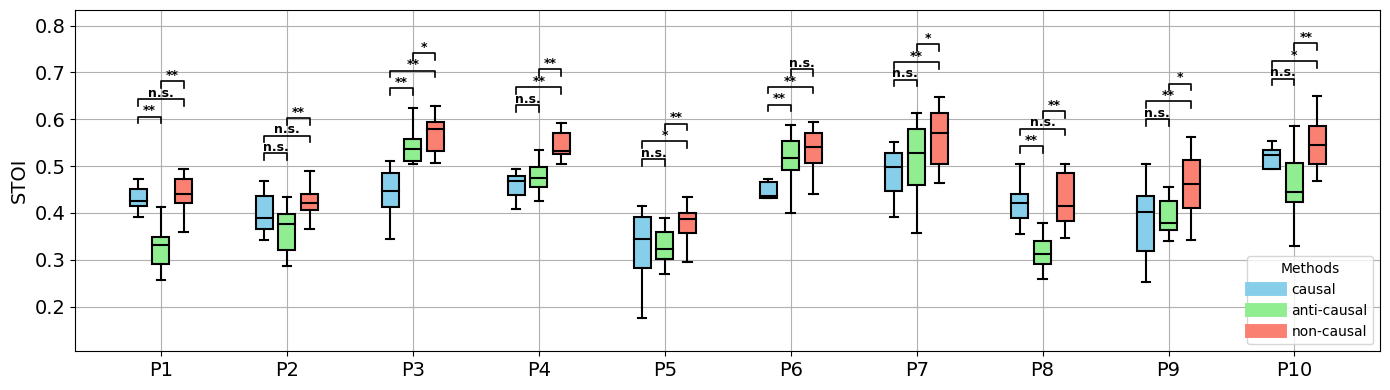

In [4]:
# ------------------------
# Choose metric 
# ------------------------
metric = "STOI"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    # "causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_777_ker_7500_T_6_causal.pkl",
    # "anti-causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_777_ker_7500_T_6_anti_causal.pkl",
    "causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_causal.pkl",
    "anti-causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_anti_causal.pkl",
    "non-causal": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# Prepare boxplot data
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []
##
causal_stois = []
anticausal_stois = []
width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# Plot
fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE)
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
# colors = ["skyblue", "lightgreen", "salmon", "plum"]
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"P{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
# ax.set_title(f"Effect of Causality in Convolutions", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")
ax.grid(True) 

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.15, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
pairs = [("causal", "anti-causal"), ("causal", "non-causal"), ("anti-causal", "non-causal")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    raw_pvals = []

    # ---- FIRST LOOP: compute raw p-values (unchanged structure) ----
    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative='two-sided')
        except Exception:
            pval = 1.0

        raw_pvals.append(pval)

        ## save stoi-scores for later
        if m1=='causal' and m2=='anti-causal':
            causal_stois.append(a)
            anticausal_stois.append(b)

    # ---- Holm–Bonferroni correction ----
    sorted_idx = np.argsort(raw_pvals)
    sorted_pvals = np.array(raw_pvals)[sorted_idx]
    holm_adjusted = np.empty_like(sorted_pvals)

    for k, p in enumerate(sorted_pvals):
        holm_adjusted[k] = min(p * (m_bonf - k), 1.0)

    for k in range(1, m_bonf):
        holm_adjusted[k] = max(holm_adjusted[k], holm_adjusted[k-1])

    p_adj_all = np.empty_like(holm_adjusted)
    p_adj_all[sorted_idx] = holm_adjusted

    # ---- SECOND LOOP: identical to original, only p_adj replaced ----
    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)

        p_adj = p_adj_all[level]   # replaces min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig('/home/ahmed348/TCNN_repo/figures/effect_of_causality.pdf', bbox_inches='tight', dpi=DPI)
# tpl_save(
#     figure=fig,
#     filepath="/home/ahmed348/TCNN_repo/tex_files/effect_of_causality.tex"
# )
# print(causal_stois[0])
# print(anticausal_stois[0]) 
# x = np.array(causal_stois)
# print(x.shape)
# print(x[0][3])
# np.save('/home/ahmed348/TCNN_repo/pkl_files/causal_stois.npy', np.array(causal_stois))
# np.save('/home/ahmed348/TCNN_repo/pkl_files/anticausal_stois.npy', np.array(anticausal_stois))

### **Effect of speech only evaluation**

In [ ]:
# ------------------------
# Choose metric
# ------------------------
metric = "PCC"   # change to "STOI" or "PCC" if needed

# ------------------------
# Load result files
# ------------------------
files = {
    "without silence": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_speech_only.pkl",
    # "silence_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_579_dil_151515_ker_7500_T_6_sil_only.pkl", 
    "with silence": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order =  list(files.keys())
results = {}
for method, fpath in files.items():
    with open(fpath, "rb") as f:
        data = pickle.load(f)
        results[method] = data[metric]  # list of n_subjects, each with 10 folds

# ------------------------
# Prepare boxplot data
# ------------------------
n_subjects = len(next(iter(results.values())))   # should be 10
methods = list(results.keys())
n_methods = len(methods)

positions = []
box_data = []
labels = []

width = 0.18  # spacing between methods
for subj_idx in range(n_subjects):
    for m_idx, method in enumerate(methods):
        subj_data = results[method][subj_idx]  # list of folds for this subject
        box_data.append(subj_data)
        # center around subject index
        positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
        labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

# ------------------------
# Plot
# ------------------------
fig, ax = plt.subplots(figsize=FIGSIZE)
bp = ax.boxplot(
    box_data,
    positions=positions,
    vert=True,
    widths=0.75*width,
    patch_artist=True,
    showfliers=False,
    medianprops={'color': 'black', 'linewidth': 1.5},
    whiskerprops={'linewidth': 1.5, 'color': 'black'},
    capprops={'linewidth': 1.5, 'color': 'black'},
    boxprops={'linewidth': 1.5},
)

# Assign colors (extendable if more methods are added)
colors = COLORS 
# colors = ["skyblue", "lightgreen", "salmon", "plum"]
for m_idx, color in enumerate(colors[:n_methods]):
    for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
        bp["boxes"][patch_idx].set_facecolor(color)

# X-axis ticks at subject centers
ax.set_xticks(range(1, n_subjects+1))
ax.set_xticklabels([f"P{i+1}" for i in range(n_subjects)], rotation=0)
ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

if metric == 'PCC':
    ax.set_ylabel('correlation', fontsize=YLABEL_FONTSIZE)
else:
    ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
# ax.set_title(f"Effect of speech-only performance across Subjects", fontsize=TITLE_FONTSIZE)

# Legend
for m_idx, method in enumerate(methods):
    ax.plot([], c=colors[m_idx], label=method, linewidth=10)
ax.legend(title="Methods")
ax.grid(True) 

# Extend ylim for stars
data_list = box_data
all_data = np.concatenate(data_list)
yrange = all_data.max() - all_data.min()
ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)
ax.grid(True) 

# Significance stars
pairs = [("without silence", "with silence")]
m_bonf = len(pairs)

base_offset = yrange * 0.05
bracket_width = yrange * 0.03 # 0.03

for s_idx in range(n_subjects):
    start_idx = s_idx * n_methods
    subj_positions = [positions[start_idx + m] for m in range(n_methods)]
    subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
    ymax = max(max(arr) for arr in subj_data_arrays)

    for level, (m1, m2) in enumerate(pairs):
        m1_idx = method_order.index(m1)
        m2_idx = method_order.index(m2)
        # a, b = subj_data_arrays[m1_idx], subj_data_arrays[m2_idx]
        a, b = results[m1][s_idx], results[m2][s_idx]

        try:
            _, pval = wilcoxon(b, a, alternative = 'two-sided')
        except Exception:
            pval = 1.0
        p_adj = min(pval * m_bonf, 1.0)
        stars = p_to_star(p_adj)

        x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
        y = ymax + base_offset + level * (base_offset + bracket_width)

        ax.plot([x1, x1, x2, x2],
                [y, y+bracket_width, y+bracket_width, y],
                lw=1.2, c='black')
        ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
# plt.savefig('/home/ahmed348/TCNN_repo/pkl_files/effect_of_speech_only_prediction.pdf', bbox_inches='tight', dpi=DPI)
# plt.show() 
tpl_save(
    figure=fig,
    filepath=f"/home/ahmed348/TCNN_repo/tex_files/effect_of_speech_only_pred_{metric}.tex"
)

In [ ]:
import numpy as np
from scipy.stats import pearsonr

files = ["/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl", \
         "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_speech_only.pkl",
]
with open(files[0], "rb") as f:
    data_regular = pickle.load(f)
    data_stoi = data_regular['STOI'] 
    data_pcc_sil_retained = data_regular['PCC'] 

with open(files[1], "rb") as f:
    data_sil_removed = pickle.load(f)
    data_pcc_sil_removed = data_sil_removed['PCC'] 

# print(data_stoi)
# print(data_pcc_sil_retained)
# print(data_pcc_sil_removed)

# convert to numpy arrays
d1 = np.array(data_stoi)
d2 = np.array(data_pcc_sil_retained)
d3 = np.array(data_pcc_sil_removed)
print(d1.shape, d2.shape, d3.shape)
# flatten
d1_flat = d1.flatten()
d2_flat = d2.flatten()
d3_flat = d3.flatten()

# correlations
r12, p12 = pearsonr(d1_flat, d2_flat)
r13, p13 = pearsonr(d1_flat, d3_flat)

print("Correlation (stoi vs pcc, sil retained):", r12, "p =", p12)
print("Correlation (stoi vs pcc, sil removed):", r13, "p =", p13)

### **Effect of speech-only and both, but both PCC and STOI in one**

In [ ]:
# ------------------------
# Load result files
# ------------------------
files = {
    "without silence": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6_speech_only.pkl",
    # "silence_only": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_579_dil_151515_ker_7500_T_6_sil_only.pkl",
    "with silence": "/home/ahmed348/TCNN_repo/pkl_files/TCNN_HGA_LFC_135_dil_151515_ker_7500_T_6.pkl",
}
method_order = list(files.keys())

# ------------------------
# Create figure with 2 subplots (PCC and STOI)
# ------------------------
metrics = ["PCC", "STOI"]
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)

for ax_idx, metric in enumerate(metrics):
    # Load data for this metric
    results = {}
    for method, fpath in files.items():
        with open(fpath, "rb") as f:
            data = pickle.load(f)
            results[method] = data[metric]  # list of n_subjects, each with 10 folds

    # ------------------------
    # Prepare boxplot data
    # ------------------------
    n_subjects = len(next(iter(results.values())))   # should be 10
    methods = list(results.keys())
    n_methods = len(methods)

    positions = []
    box_data = []
    labels = []
    width = 0.18  # spacing between methods

    for subj_idx in range(n_subjects):
        for m_idx, method in enumerate(methods):
            subj_data = results[method][subj_idx]  # list of folds for this subject
            box_data.append(subj_data)
            positions.append(subj_idx + 1 + (m_idx - (n_methods-1)/2)*width)
            labels.append(f"Subj {subj_idx+1}" if m_idx == n_methods//2 else "")

    # ------------------------
    # Plot boxplot
    # ------------------------
    ax = axes[ax_idx]
    bp = ax.boxplot(
        box_data,
        positions=positions,
        vert=True,
        widths=0.75*width,
        patch_artist=True,
        showfliers=False,
        medianprops={'color': 'black', 'linewidth': 1.5},
        whiskerprops={'linewidth': 1.5, 'color': 'black'},
        capprops={'linewidth': 1.5, 'color': 'black'},
        boxprops={'linewidth': 1.5},
    )

    # Assign colors
    for m_idx, color in enumerate(COLORS[:n_methods]):
        for patch_idx in range(m_idx, len(bp["boxes"]), n_methods):
            bp["boxes"][patch_idx].set_facecolor(color)

    # X-axis ticks at subject centers
    ax.set_xticks(range(1, n_subjects+1))
    ax.set_xticklabels([f"sub-{i+1}" for i in range(n_subjects)], rotation=0)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE_X_and_Y)

    if metric == 'PCC':
        ax.set_ylabel('correlation', fontsize=YLABEL_FONTSIZE)
    else:
        ax.set_ylabel(metric, fontsize=YLABEL_FONTSIZE)
    # if ax_idx == 0:
    #     ax.set_title(f"Comparison between speech-only and speech+silence predictions", fontsize=TITLE_FONTSIZE)

    ax.grid(True)

    # Extend ylim for stars
    data_list = box_data
    all_data = np.concatenate(data_list)
    yrange = all_data.max() - all_data.min()
    ax.set_ylim(all_data.min() - yrange*0.025, all_data.max() + yrange*0.39)

    # Significance stars
    pairs = [("without silence", "with silence")]
    m_bonf = len(pairs)
    base_offset = yrange * 0.05
    bracket_width = yrange * 0.03

    for s_idx in range(n_subjects):
        start_idx = s_idx * n_methods
        subj_positions = [positions[start_idx + m] for m in range(n_methods)]
        subj_data_arrays = [data_list[start_idx + m] for m in range(n_methods)]
        ymax = max(max(arr) for arr in subj_data_arrays)

        for level, (m1, m2) in enumerate(pairs):
            m1_idx = method_order.index(m1)
            m2_idx = method_order.index(m2)
            a, b = results[m1][s_idx], results[m2][s_idx]

            try:
                _, pval = wilcoxon(b, a, alternative='two-sided')
            except Exception:
                pval = 1.0
            p_adj = min(pval * m_bonf, 1.0)
            stars = p_to_star(p_adj)

            x1, x2 = subj_positions[m1_idx], subj_positions[m2_idx]
            y = ymax + base_offset + level * (base_offset + bracket_width)

            ax.plot([x1, x1, x2, x2],
                    [y, y+bracket_width, y+bracket_width, y],
                    lw=1.2, c='black')
            ax.text((x1+x2)/2, y+bracket_width*0.9, stars,
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout(rect=[0, 0, 1, 0.95])  # leave space at top for legend
fig.legend(
    handles=[plt.Line2D([], [], color=COLORS[i], linewidth=9, label=method) for i, method in enumerate(methods)],
    loc='upper center',
    ncol=len(methods),
    frameon=False,
    fontsize=11
)

plt.savefig(
    "/home/ahmed348/TCNN_repo/figures/effect_of_speech_only_pred.pdf",
    bbox_inches="tight",
    dpi=DPI,
)
# plt.show()
tpl_save(
    figure=fig,
    filepath="/home/ahmed348/TCNN_repo/tex_files/effect_of_speech_only_pred.tex"
)


### **receptive field calculator**

In [ ]:
k = 15
d = [1,3,4]
RF = np.ones(len(d)+1)
print(RF) 
for i in range(len(d)):
    RF[i+1] = RF[i] + d[i]*(k-1)

print(RF[1:]) 

### **Generate sEEG plot for schematic in Introduction**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_multichannel_timeseries(
    X,                  # shape: (T, C)
    max_channels=32,
    colors=("tab:blue", "tab:orange"),
    channel_spacing=None,
    linewidth=0.8
):
    T, C = X.shape
    C_plot = min(C, max_channels)
    X = X[:, :C_plot]
    if channel_spacing is None:
        channel_spacing = 1.2 * np.std(X)
    time = np.arange(T)
    split_idx = C_plot // 2
    plt.figure(figsize=(12, 6))
    for ch in range(C_plot):
        color = colors[0] if ch < split_idx else colors[1]
        plt.plot(
            time,
            X[:, ch] + ch * channel_spacing,
            color=color,
            linewidth=linewidth
        )

    plt.xlabel("Time")
    plt.ylabel("Channels (offset)")
    plt.yticks([])
    plt.box(False)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

hga_feat = np.load('/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/FEATURES/features_HGA_ONLY/sub-01_feat.npy')
lfc_feat = np.load('/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/FEATURES/features_LFC_ONLY/sub-01_feat.npy')
feat1 = hga_feat[3100:3300, 90:90+12]
feat2 = lfc_feat[3100:3300, 90:90+12]
def z_score(data):
    return (data - np.mean(data, axis=0)) / (np.std(data, axis=0) + 1e-8)
feat1_norm = z_score(feat1)
feat2_norm = z_score(feat2)
combined_feat = np.concatenate((feat1_norm, feat2_norm), axis=-1)
print(combined_feat.shape)
plot_multichannel_timeseries(
    combined_feat,
    max_channels=24,     # or 64
    colors=("red", "blue")
)

### **Generate log-mel spectrograms for schematic**

In [ ]:
spectrogram = np.load('/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/FEATURES/features_HGA_LFC/sub-01_spec.npy')
print(spectrogram.shape)
spec = spectrogram[1200:1800, :]
noise = np.random.randn(600, 80)
# spec = spec + noise * 0.9
plt.figure(figsize=(6,3))
plt.imshow(spec.T, aspect='auto')
plt.axis('off')

In [ ]:
from machine_learning import TemporalCNN_deep
from tcnn_utils import get_fold_i
import torch

DEVICE = 'cuda'
FEAT = "HGA_LFC"
feat_path = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/FEATURES/features_{FEAT}'
pts = ['sub-%02d'%i for i in range(1,11)]
for pNr, pt in enumerate(pts):
        if pNr not in [0]: # just on the first one/two patients for now 
            continue 
        print(f'pnr : {pNr}')
        spectrogram = np.load(os.path.join(feat_path,f'{pt}_spec.npy'))
        # print(f'spectrogram shape: {spectrogram.shape}')
        eeg = np.load(os.path.join(feat_path,f'{pt}_feat.npy'))
        va_labels = np.load(os.path.join(feat_path,f'{pt}_va.npy'))
        
        fold_wise_pcc = []
        fold_wise_mse = []
        MCDs = []; STOIs = []; PCC_SEQs = []; VAs = []

        for k in range(10):
            if k not in [0]: 
                continue
            print(f'patient number : {pNr+1}, fold number : {k}') 
            X_train, y_train, va_labels_train, X_test, y_test, \
                va_labels_test = get_fold_i(eeg, spectrogram, va_labels, 10, k)

            channel_means_train = np.mean(X_train, axis=0)  # Shape: (127,)
            channel_stds_train = np.std(X_train, axis=0)    # Shape: (127,)
            channel_means_test = np.mean(X_test, axis=0)  # Shape: (127,)
            channel_stds_test = np.std(X_test, axis=0)    # Shape: (127,)

            X_train = (X_train - channel_means_train)/channel_stds_train
            X_test = (X_test - channel_means_test)/channel_stds_test

            X_train = torch.from_numpy(X_train)
            y_train = torch.from_numpy(y_train)
            X_test = torch.from_numpy(X_test)
            y_test = torch.from_numpy(y_test)

model = TemporalCNN_deep(X_train.shape[-1], 80, [15, 15, 15], [1,3,5], 128).to(DEVICE) ## for HGA-only and HGA-LFC with fc<51
PATH = f'/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/SAVED_WEIGHTS/weights_{FEAT}_135_dil_151515_ker_7500_T_6/weights_sub-01_fold_1.pth'
model.load_state_dict(torch.load(PATH, weights_only=True))
model.eval() 

a = 1200; b = a + 600
sample_X = X_train[a:b, :].unsqueeze(0).float().to(DEVICE) 
y_pred = model(sample_X)
print(f'prediction shape : {y_pred.shape}')
gt_spec = y_train[a:b, :]

pred_spec = y_pred[0].cpu().detach().numpy()
combined_min = min(pred_spec.min(), gt_spec.min())
combined_max = max(pred_spec.max(), gt_spec.max())
# Use the same vmin and vmax for both
plt.figure(figsize=(6,3))
plt.imshow(pred_spec.T, vmin=combined_min, vmax=combined_max, aspect='auto')
plt.axis('off')
plt.show()

### **Generate sample audio for schematic**

In [ ]:
from pynwb import NWBHDF5IO

filepath = '/scratch/gilbreth/ahmed348/public_datasets/Dutch_Dataset/sub-01/ieeg/sub-01_task-wordProduction_ieeg.nwb'
io = NWBHDF5IO(filepath, 'r')
nwbfile = io.read()
audio = nwbfile.acquisition['Audio'].data[:]
print(audio.shape)
print(f'audio time duration : {len(audio)/48000} sec')
sr = 48000
audio_sample = audio[int(12*sr):int(18*sr)]
print(audio_sample.shape)
plt.plot(audio_sample)
plt.axis('off')

### compare predicted audio waveform with ground truth!

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.io import wavfile
import os

def plot_audio_comparison(path1, path2):
    # Load the audio files
    fs1, data1 = wavfile.read(path1)
    fs2, data2 = wavfile.read(path2)

    # Function to normalize data and handle stereo
    def process_data(data, fs):
        # If stereo, take only the first channel for comparison
        if len(data.shape) > 1:
            data = data[:, 0]
        # Calculate time axis in seconds
        length = data.shape[0] / fs
        time = np.linspace(0., length, data.shape[0])
        data = data/np.max(np.abs(data))
        return time, data

    time1, signal1 = process_data(data1, fs1)
    time2, signal2 = process_data(data2, fs2)

    # Create the figure
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    # Plot first audio file
    ax1.plot(time1, signal1, color='steelblue', linewidth=0.5)
    ax1.set_title(f"File 1: {os.path.basename(path1)}")
    ax1.set_xlabel("Time (s)")
    ax1.set_ylabel("Amplitude")
    ax1.grid(True, alpha=0.3)

    # Plot second audio file
    ax2.plot(time2, signal2, color='darkorange', linewidth=0.5)
    ax2.set_title(f"File 2: {os.path.basename(path2)}")
    ax2.set_xlabel("Time (s)")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Replace these with your actual file paths
file_path_1 = '/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/RESULTS/results_HGA_LFC_135_dil_151515_ker_7500_T_6/sub-03_fold_4_gt.wav'
# file_path_2 = '/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/RESULTS/results_HGA_LFC_135_dil_151515_ker_7500_T_6/sub-03_fold_4_pred.wav'
file_path_2 = '/scratch/gilbreth/ahmed348/Dutch_dataset_features/TCNN_folder/RESULTS/results_VOCALMIND_vocalmind_7500_T_6/sub-03_fold_1_pred.wav'
# Execute the plot
plot_audio_comparison(file_path_1, file_path_2)